In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
image = cv2.imread('sar_1.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) 

mean = 0
stddev = 100
noise_gauss = np.zeros(image_gray.shape, np.uint8)
cv2.randn(noise_gauss, mean, stddev)

image_noise_gauss = cv2.add(image_gray,noise_gauss)


In [3]:
m, n = 5, 5
pad_h, pad_w = m // 2, n // 2
alpha = 2
d = alpha // 2


def alpha_filter(a):
    pixels = a.flatten()
    pixels.sort()

    trimmed = pixels[d:-d]

    return np.mean(trimmed)


def proc(img, filter):
    h, w = img.shape
    padded = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode="edge")
    img_res = np.zeros_like(img)

    for i in range(h):
        for j in range(w):
            img_res[i, j] = filter(padded[i : i + m, j : j + n])
    return img_res.astype(np.uint8)


res = proc(image_noise_gauss, alpha_filter)

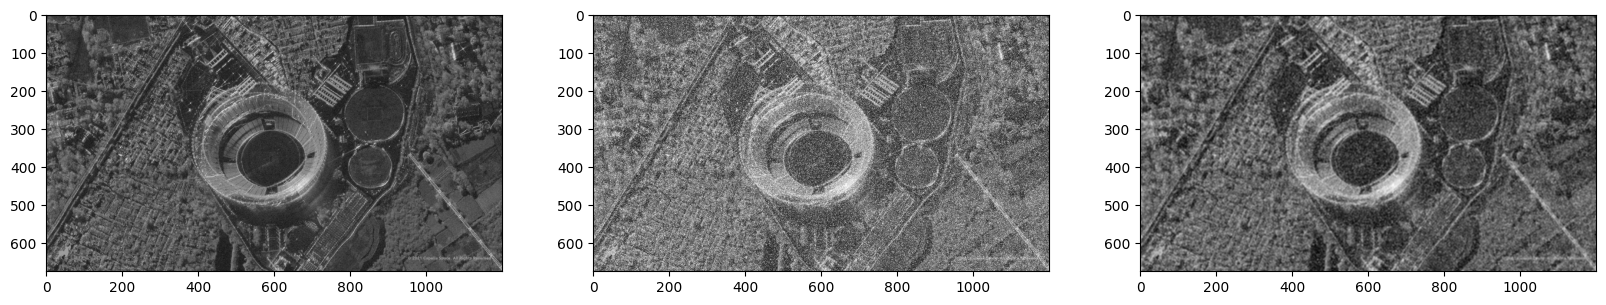

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(20, 10))
ax[0].imshow(image_gray, cmap="gray")
ax[1].imshow(image_noise_gauss, cmap="gray")
ax[2].imshow(res, cmap="gray")